In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## All of the parameters below need to go into the simulate() as parameters. Chat can put it all in  a `run_scenario()` wrapper function
- what would 1 year at current process be (lisa=0, 167 to vangard and current starting values). this can be a good sanity check of code overall
- compare simulations for lisa vs. full vangard 

In [60]:
def monthly_rate(annual_rate):
    return (1 + annual_rate) ** (1/12) - 1
    

def plot_scenario(df, lower_v, upper_v, total_lower, total_upper, scenario_name):
    
    fig, Ax = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)

    # -----------------------
    # LEFT: Individual pots
    # -----------------------
    ax = Ax[0]

    ax.plot(df.index, df["Vanguard"], label="Vanguard (expected)")
    ax.fill_between(
        df.index,
        lower_v,
        upper_v,
        alpha=0.25,
        label="Vanguard uncertainty"
    )

    ax.plot(df.index, df["LISA"], label="LISA")
    ax.plot(df.index, df["Emergency"], label="Emergency")

    ax.set_ylabel("£")
    ax.set_title("Savings by pot")
    ax.legend()
    ax.grid(True)
    ax.tick_params(axis="x", rotation=45)

    # -----------------------
    # RIGHT: Total wealth
    # -----------------------
    ax = Ax[1]

    ax.plot(df.index, df["Total"], label="Total (expected)", color="black")
    ax.fill_between(
        df.index,
        total_lower,
        total_upper,
        alpha=0.25,
        label="Total uncertainty (from Vanguard)"
    )

    ax.set_ylabel("£")
    ax.set_title("Total projected wealth")
    ax.legend()
    ax.grid(True)
    ax.tick_params(axis="x", rotation=45)

    fig.suptitle(scenario_name)
    plt.show()


def print_summary(df, lower_v, upper_v, scenario_name="Name"):

    final_date = df.index[-1]

    emergency = df.loc[final_date, "Emergency"]
    lisa = df.loc[final_date, "LISA"]
    vanguard = df.loc[final_date, "Vanguard"]
    total = df.loc[final_date, "Total"]

    # Propagate Vanguard uncertainty into total
    total_lower = total - vanguard + lower_v.iloc[-1]
    total_upper = total - vanguard + upper_v.iloc[-1]

    print(f"\n========== SAVINGS SUMMARY for {scenario_name} ==========")
    print(f"Date: {final_date.strftime('%B %Y')}\n")

    print(f"Emergency fund: £{emergency:,.0f}")
    print(f"LISA:           £{lisa:,.0f}")
    print(f"Vanguard:       £{vanguard:,.0f}")

    print("\n-----------------------------------")
    print(f"Total (expected): £{total:,.0f}")
    print(f"Total range:     £{total_lower:,.0f}  →  £{total_upper:,.0f}")

    downside = (total_lower / total - 1) * 100
    upside = (total_upper / total - 1) * 100

    print(f"Uncertainty:     {downside:.1f}%  to  +{upside:.1f}%")
    print("===================================\n")





def run_scenario(
    years=10,
    start_date="2026-01-01",
    initial_emergency=7000,
    initial_lisa=0,
    initial_global=0,
    initial_sp500=0,
    monthly_emergency=0,
    monthly_lisa=0,
    monthly_vanguard=167,
    global_weight=0.7,
    sp500_weight=0.3,
    global_return=0.065,
    sp500_return=0.07,
    global_vol=0.15,
    sp500_vol=0.18,
    lisa_return=0.01,
    show_plot=True,
    scenario_name="Scenario"
):

    months = years * 12
    dates = pd.date_range(start=start_date, periods=months, freq="MS")

    contribs = pd.DataFrame(index=dates)
    contribs["emergency"] = monthly_emergency
    contribs["lisa"] = monthly_lisa
    contribs["vanguard"] = monthly_vanguard


    emergency = np.zeros(months)
    lisa = np.zeros(months)
    global_fund = np.zeros(months)
    sp500_fund = np.zeros(months)

    emergency[0] = initial_emergency
    lisa[0] = initial_lisa
    global_fund[0] = initial_global
    sp500_fund[0] = initial_sp500

    r_global = monthly_rate(global_return)
    r_sp500 = monthly_rate(sp500_return)
    r_lisa = monthly_rate(lisa_return)

    for t in range(1, months):
        emergency[t] = emergency[t-1] + contribs.iloc[t]["emergency"]

        lisa[t] = (
            lisa[t-1] * (1 + r_lisa)
            + contribs.iloc[t]["lisa"] * 1.25
        )

        global_fund[t] = (
            global_fund[t-1] * (1 + r_global)
            + contribs.iloc[t]["vanguard"] * global_weight
        )

        sp500_fund[t] = (
            sp500_fund[t-1] * (1 + r_sp500)
            + contribs.iloc[t]["vanguard"] * sp500_weight
        )

    df = pd.DataFrame({
        "Emergency": emergency,
        "LISA": lisa,
        "Global": global_fund,
        "S&P500": sp500_fund
    }, index=dates)

    df["Vanguard"] = df["Global"] + df["S&P500"]
    df["Total"] = df["Emergency"] + df["LISA"] + df["Vanguard"]

    # --- Uncertainty ---
    sigma = np.sqrt(
        (global_weight * global_vol) ** 2 +
        (sp500_weight * sp500_vol) ** 2
    )

    t_years = np.arange(months) / 12

    lower_v = df["Vanguard"] * np.exp(-sigma * np.sqrt(t_years))
    upper_v = df["Vanguard"] * np.exp(sigma * np.sqrt(t_years))

    total_lower = df["Total"] - df["Vanguard"] + lower_v
    total_upper = df["Total"] - df["Vanguard"] + upper_v

    if show_plot:
        plot_scenario(
            df,
            lower_v,
            upper_v,
            total_lower,
            total_upper,
            scenario_name
        )

    print_summary(df, lower_v, upper_v, scenario_name=scenario_name)

    final = df.iloc[-1]
    final_lower = total_lower.iloc[-1]
    final_upper = total_upper.iloc[-1]

    return df, final["Total"], final_lower, final_upper

## Testing the simulation

- If initial values are £0 and monthly deposits are also £0 then total after 10 years is £0
- For 10 years without investment (`return=0`), starting from £0 and saving £500 per month would equate to £60,000. With investment (70  global($r=0.065$), 30 : s&p($r=0.07$)), this increases to £83,000. Hence 10 years of investment with £0 initial amount results in £23,000 growth
- Simulating no monthly contribution but a an initial lump sum for 10 years returns expected value 


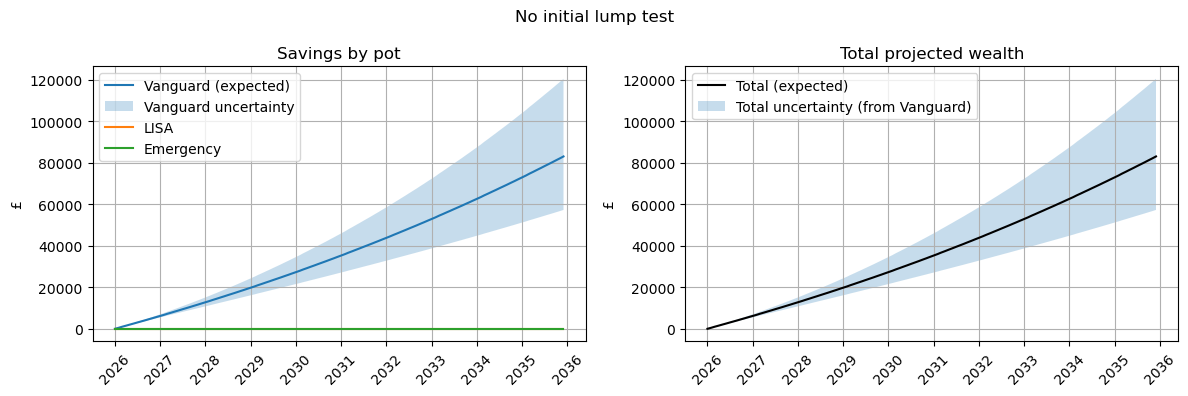


========== SAVINGS SUMMARY for No initial lump test ==========
Date: December 2035

Emergency fund: £0
LISA:           £0
Vanguard:       £83,057

-----------------------------------
Total (expected): £83,057
Total range:     £57,266  →  £120,463
Uncertainty:     -31.1%  to  +45.0%



In [62]:
df1, total1, low1, up1 = run_scenario(
    years=10,
    start_date="2026-01-01",
    initial_emergency=0,
    initial_lisa=0,
    initial_global=0,
    initial_sp500=0,
    monthly_emergency=0,
    monthly_lisa=0, # maximum is 333
    monthly_vanguard=500,
    global_return=0.065,
    sp500_return=0.07,
    scenario_name="No initial lump test"
)

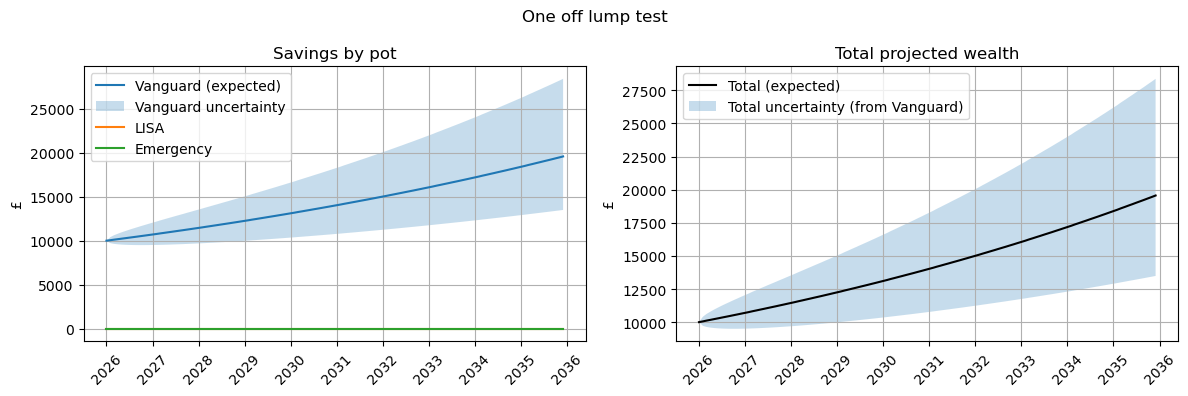


========== SAVINGS SUMMARY for One off lump test ==========
Date: December 2035

Emergency fund: £0
LISA:           £0
Vanguard:       £19,561

-----------------------------------
Total (expected): £19,561
Total range:     £13,487  →  £28,371
Uncertainty:     -31.1%  to  +45.0%



19671.513572895663

In [64]:
years = 10
lump = 10000

df1, total1, low1, up1 = run_scenario(
    years=years,
    start_date="2026-01-01",
    initial_emergency=0,
    initial_lisa=0,
    initial_global=0,
    initial_sp500=lump,
    monthly_emergency=0,
    monthly_lisa=0, # maximum is 333
    monthly_vanguard=0,
    global_return=0,#0.065,
    sp500_return=0.07,
    scenario_name="One off lump test"
)

def compound_growth(p, c, r=0.07, n=10):
    return p*(1 + r)**n + (c/r) * ((1 + r)**n - 1)

compound_growth(lump, 0, r=0.07, n=years)

## Real simulations

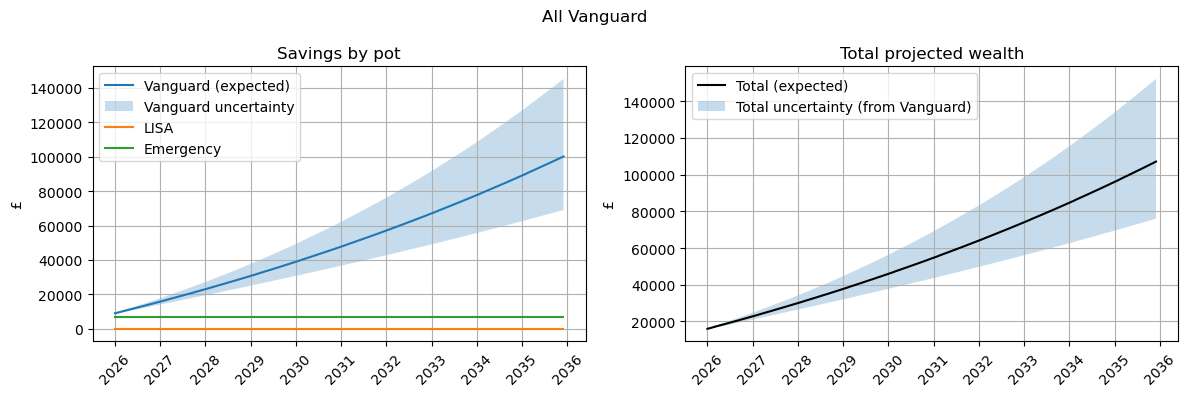


========== SAVINGS SUMMARY for All Vanguard ==========
Date: December 2035

Emergency fund: £7,000
LISA:           £0
Vanguard:       £100,129

-----------------------------------
Total (expected): £107,129
Total range:     £76,037  →  £152,224
Uncertainty:     -29.0%  to  +42.1%



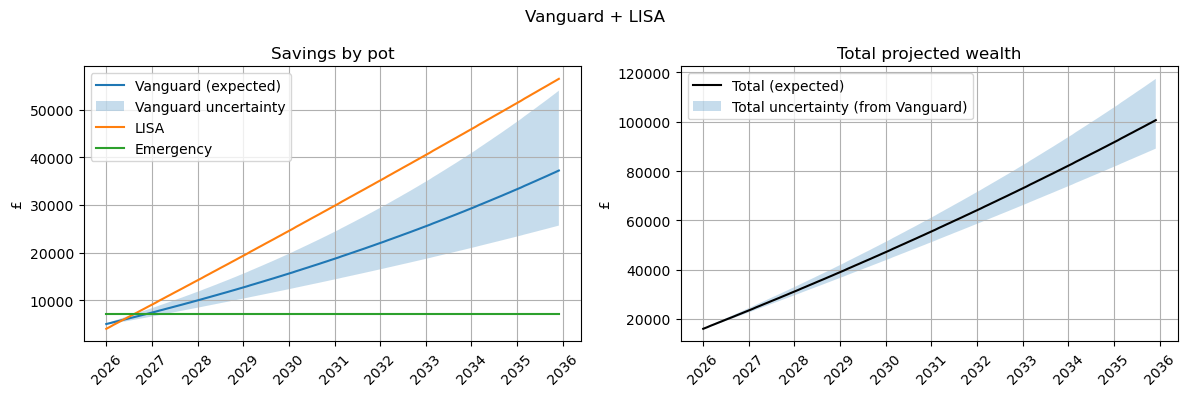


========== SAVINGS SUMMARY for Vanguard + LISA ==========
Date: December 2035

Emergency fund: £7,000
LISA:           £56,453
Vanguard:       £37,211

-----------------------------------
Total (expected): £100,664
Total range:     £89,109  →  £117,422
Uncertainty:     -11.5%  to  +16.6%



In [74]:
# Run a 10 year All vanguard simulation
df1, total1, low1, up1 = run_scenario(
    years=10,
    start_date="2026-01-01",
    initial_emergency=7000,
    initial_lisa=0,
    initial_global=6000,
    initial_sp500=3000,
    monthly_emergency=0,
    monthly_lisa=0,
    monthly_vanguard=500,
    global_return=0.065,
    sp500_return=0.07,
    scenario_name="All Vanguard"
)

# Run a 10 year vanguard + LISA simulation
df1, total1, low1, up1 = run_scenario(
    years=10,
    start_date="2026-01-01",
    initial_emergency=7000,
    initial_lisa=4000,
    initial_global=3500,
    initial_sp500=1500,
    monthly_emergency=0,
    monthly_lisa=333,
    monthly_vanguard=167,
    global_return=0.065,
    sp500_return=0.07,
    scenario_name="Vanguard + LISA"
)

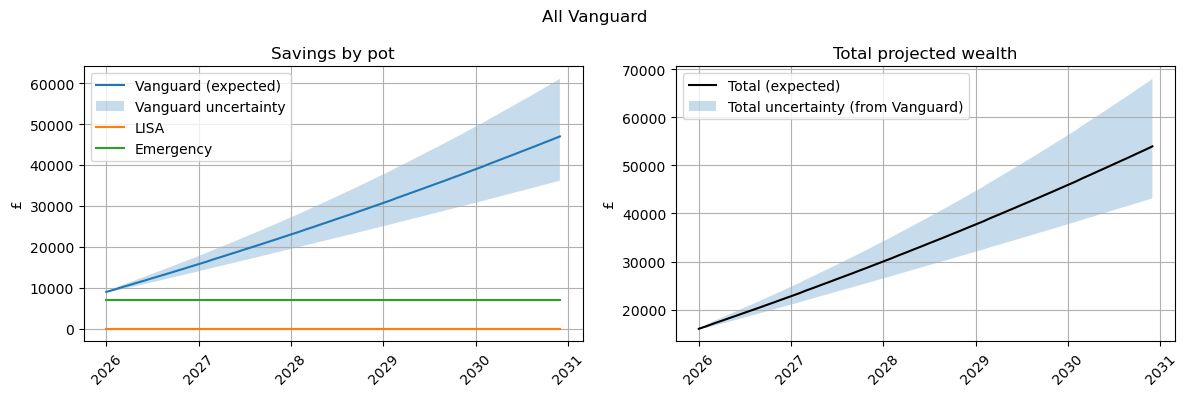


========== SAVINGS SUMMARY for All Vanguard ==========
Date: December 2030

Emergency fund: £7,000
LISA:           £0
Vanguard:       £46,972

-----------------------------------
Total (expected): £53,972
Total range:     £43,153  →  £68,030
Uncertainty:     -20.0%  to  +26.0%



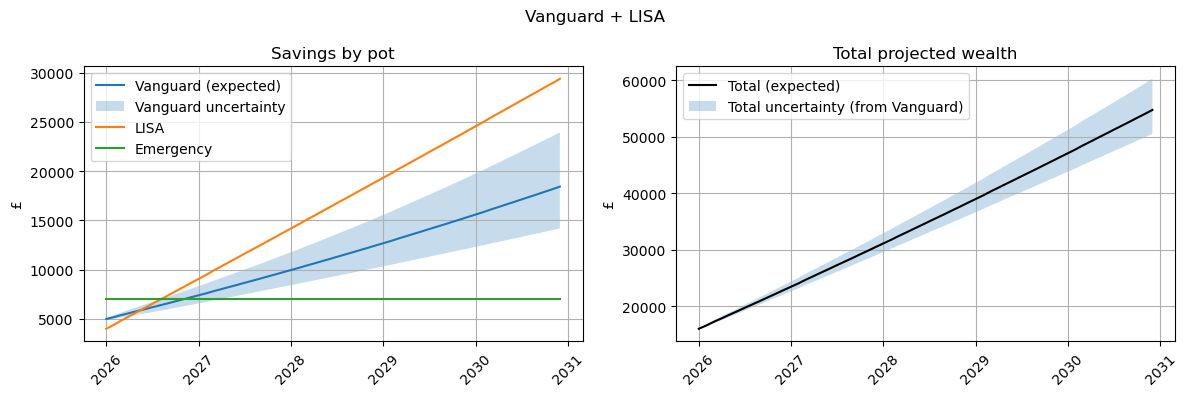


========== SAVINGS SUMMARY for Vanguard + LISA ==========
Date: December 2030

Emergency fund: £7,000
LISA:           £29,360
Vanguard:       £18,422

-----------------------------------
Total (expected): £54,782
Total range:     £50,538  →  £60,295
Uncertainty:     -7.7%  to  +10.1%



In [76]:
# Run a 10 year All vanguard simulation
df1, total1, low1, up1 = run_scenario(
    years=5,
    start_date="2026-01-01",
    initial_emergency=7000,
    initial_lisa=0,
    initial_global=6000,
    initial_sp500=3000,
    monthly_emergency=0,
    monthly_lisa=0,
    monthly_vanguard=500,
    global_return=0.065,
    sp500_return=0.07,
    scenario_name="All Vanguard"
)

# Run a 10 year vanguard + LISA simulation
df1, total1, low1, up1 = run_scenario(
    years=5,
    start_date="2026-01-01",
    initial_emergency=7000,
    initial_lisa=4000,
    initial_global=3500,
    initial_sp500=1500,
    monthly_emergency=0,
    monthly_lisa=333,
    monthly_vanguard=167,
    global_return=0.065,
    sp500_return=0.07,
    scenario_name="Vanguard + LISA"
)